## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?

*The difference between regression and classification is the outcome variable. If the outcome variable is categorical we are doing classification and if it is numeric we are doing regression. The goal with regression is to estimate a real quantity and the goal with classification is to assign groups to observations*

2. What is a confusion table/matrix? What does it help us understand about a model's performance? 

*A confusion matrix is a matrix that will comapre the model's prediction classification to the true classification. It shows the correctly and incorrectly classified observations. This helps us understand where the model is making mistakes to help us determine a model's accuracy*

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?

*Accuracy is just the proportion of correct predictions over total predictions. It is the primary measure that determines whether a model is good or bad*

4. What does the root mean squared error quantify about a particular model?

*The root mean squared error is sort of the equivalent of a measurement for regression like accuracy for classification. It's the measure of prediction error between true values and predicted values; having a lower RMSE means a better prediction power.*

5. What are overfitting and underfitting? 

*If k is too low, the model is overfitting and if k is too high, the model is underfitting. Overfitting is when the model is overly sensitive because the k is too low and there aren't enough data points. Underfitting is when the model averages itself out over too many data points and misses out on important patterns*

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?

*Splitting the data up makes us evaluate the model on unseen examples which when or if the model gets published, is the goal. Choosing the value of k by evaluating accuracy or RMSE improves model performance because if you chose k only based on the training set, it will perform well because it is used to training with similar values of k but they don't always perform well generally; by testing out different values of k and picking the only with the best accuracy or RMSE, it helps balance possible over/underfitting and improves final model performance.*

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

*As a prediction, strengths include that it is easily interpretable and easy to score for accuracy, weaknesses are that it can be pretty uncertain at times. When reported as a probability distribution over class labels, 2 strengths are that confidence is shown clearly and it's useful for rankings like top 10 something, a weakness is that it can be harder to interpret and explain*

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [4]:
#1
import pandas as pd
import numpy as np

df = pd.read_csv("data2/land_mines.csv")
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [5]:
df.shape
df.isna().sum()
df["mine_type"].value_counts().sort_index()
df[["voltage","height","soil"]].describe()

,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


In [6]:
#2
from sklearn.model_selection import train_test_split
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.50,random_state=1,stratify=y)

print(X_train.shape, X_test.shape)

(169, 3) (169, 3)


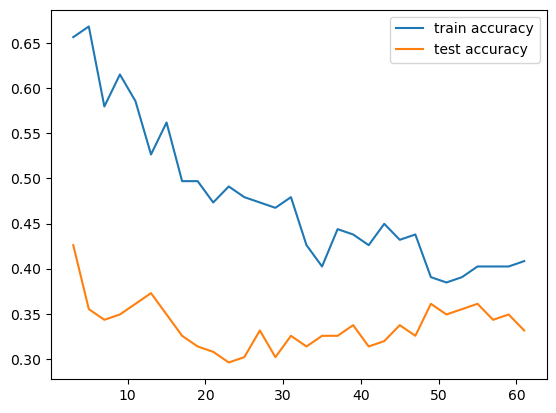

In [7]:
#3
#Normalize with min max
def minmax_scale(train_df, test_df):
    train_min = train_df.min()
    train_max = train_df.max()
    train_scaled = (train_df - train_min) / (train_max - train_min)
    test_scaled  = (test_df  - train_min) / (train_max - train_min)
    return train_scaled, test_scaled

u_train, u_test = minmax_scale(X_train, X_test)

#fit kNN classifier
from sklearn.neighbors import KNeighborsClassifier

k_grid = np.array([2*k + 1 for k in range(1, 31)])
train_accs = []
test_accs = []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(u_train, y_train)
    train_accs.append(model.score(u_train, y_train))
    test_accs.append(model.score(u_test, y_test))

#plot to see what the best value is for k
import matplotlib.pyplot as plt
plt.figure()
plt.plot(k_grid, train_accs, label="train accuracy")
plt.plot(k_grid, test_accs, label="test accuracy")
plt.legend()
plt.show()

#3) The best testing and training accuracy for k looks to be 3 with a testing accuracy of around 0.43 and a training accuracy of around 0.66. This 
# way of graphing all the k values testing and training accuracies shows me which k value is optimal to avoid over/underfitting.

In [8]:
#4.
k=3
model = KNeighborsClassifier(n_neighbors=k)
model.fit(u_train, y_train)
y_hat = model.predict(u_test)

overall_acc = (y_hat == y_test).mean()
print(overall_acc)

conf = pd.crosstab(y_test,y_hat,
    rownames=["Actual"],
    colnames=["Predicted"])
conf

#The overall test accuracy is 0.426 which isn't great and we can see it in the confusion matrix. The model does well for type 1 and type 2 mines
#with ratios of 23/35 and 31/35 respectively, but does very poorly for type 3,4, and 5, mines, with type 4 having a 1/35 actual vs predicted accuracy.

0.4260355029585799


Predicted,1,2,3,4,5
Actual,,,,,
1,23,0,4,2,6
2,0,31,0,4,0
3,9,1,12,6,5
4,19,4,5,1,4
5,12,2,8,6,5


In [9]:
#5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. 
# Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

# The overall accuracy of the model is 42.6% which isn't great seeing that by randomly guessing, we would achieve 20% in the long run and also
# the confusion matrix shows a huge weakness. A large part of the model's prediction accuracy comes from type 1 and type 2 mines, but it does very
# poorly for type 3,4, and 5 mines. In practice, I would advise someone to use this model as support for their decision making for type 1 and 
# type 2 mines having higher confidence while maybe using another model or getting an expert for type 3 and especially type 4 and 5 mines.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [10]:
#1
df = pd.read_csv('data2/USA_cars_datasets.csv')
print(df.shape)
df = df[['price', 'year', 'mileage']]
print(df.isna().sum())
df.head()

(2499, 13)
price      0
year       0
mileage    0
dtype: int64


,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [11]:
#2
X = df[["year", "mileage"]]
y = df["price"]

def minmax_scale(train_df, test_df):
    train_min = train_df.min()
    train_max = train_df.max()
    train_scaled = (train_df - train_min) / (train_max - train_min)
    test_scaled  = (test_df  - train_min) / (train_max - train_min)
    return train_scaled, test_scaled


In [12]:
#3
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=4)

X_train.shape, X_test.shape

((1999, 2), (500, 2))

k=  3  MSE=131935947.85


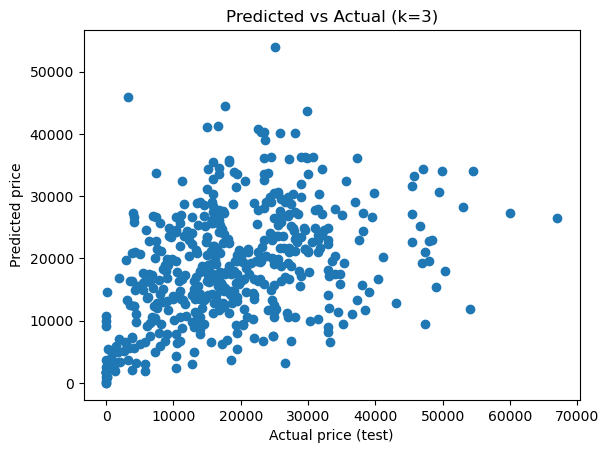

k= 10  MSE=107332316.95


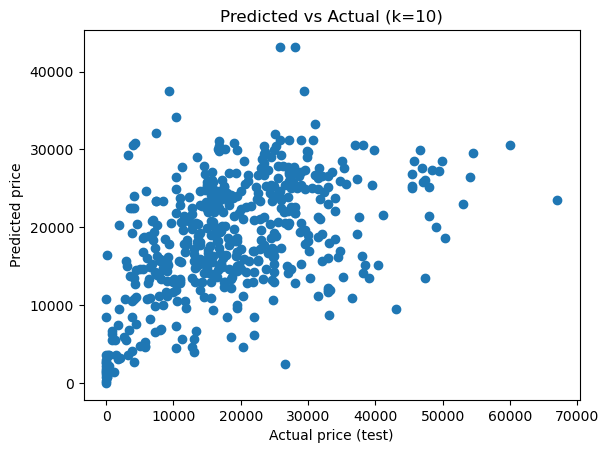

k= 25  MSE=99054478.24


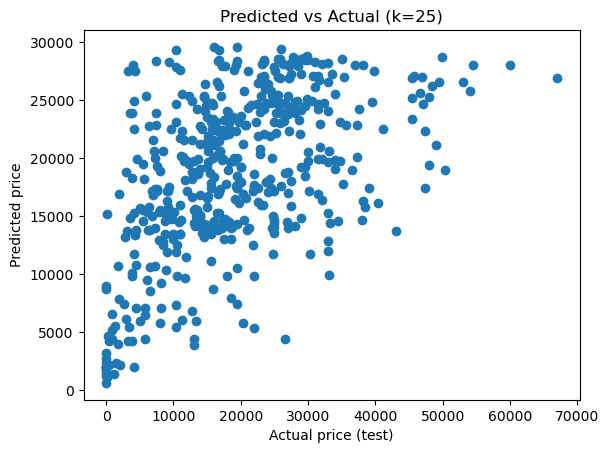

k= 50  MSE=96527511.24


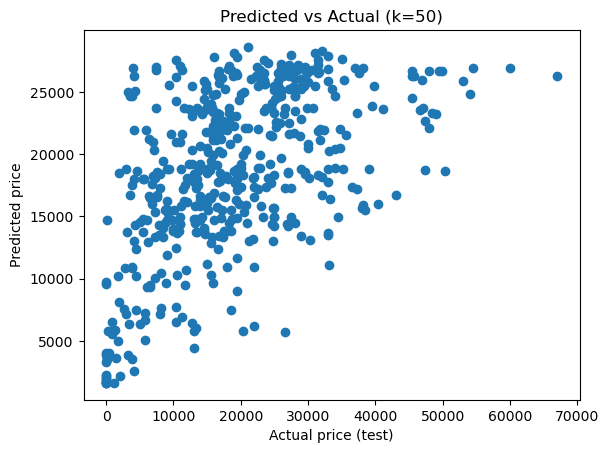

k=100  MSE=95392983.55


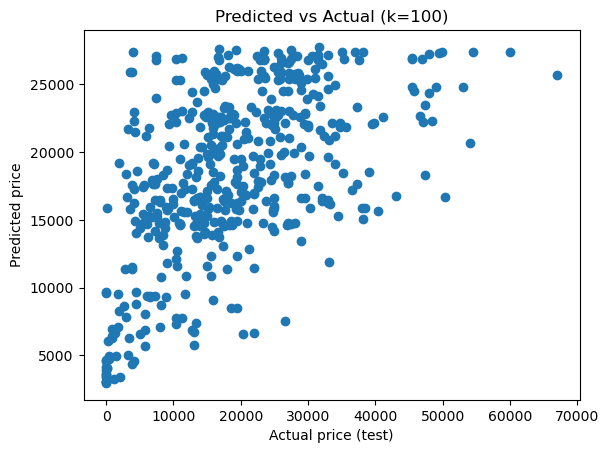

k=300  MSE=95995604.54


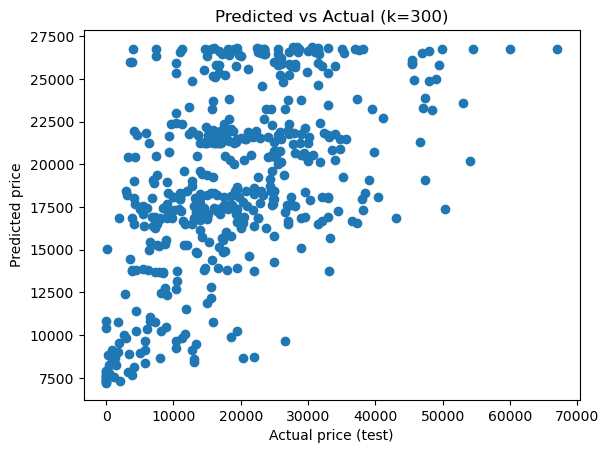

In [ ]:
#4
from sklearn.neighbors import KNeighborsRegressor

# First, scale the training and test features (this was missing)
u_train, u_test = minmax_scale(X_train, X_test)

ks = [3, 10, 25, 50, 100, 300]
mse_results = {}

for k in ks:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(u_train, y_train)
    
    y_hat = model.predict(u_test)
    mse = np.mean((y_test - y_hat)**2)
    mse_results[k] = mse
    
    print(f"k={k:>3}  MSE={mse:.2f}")
    
    plt.figure()
    plt.scatter(y_test, y_hat)
    plt.xlabel("Actual price (test)")
    plt.ylabel("Predicted price")
    plt.title(f"Predicted vs Actual (k={k})")
    plt.show()

#As k increases, I'm noticing that the MSE is actually decreasing which is weird because I was expecting it to increase with k. In the context
#of the dataset this means that as the number of predictions increases, the data averages out more and the model makes better predictions over more cars

In [ ]:
#5 The optimal value for k in the test set is 300 with the lowest MSE.

In [ ]:
#6 The smaller values of k, like k=3 were overfitting with signs of very extreme predictions and sensitive predictions which explains why it had the
#highest MSE. For the larger values of k like 100 or 300, the scatterplots became rather smooth which to me showed signs of underfitting, with
#a reduced variability but also compresses towards the mean and while this might have increased performance, it might not make for the most balanced model.
#When k was around 25 or 50, the predictions were smooth and rather stable with a good balance of variability and bias making it balanced for generalization.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [19]:
#1
df = pd.read_csv('data2/airbnb_hw.csv')
df = df.loc[:, ['Review Scores Rating', 'Price', 'Beds']]
print(df.shape)
df.head()

(30478, 3)


,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
4,96.0,549,3.0


In [20]:
#2
missing_df = df.loc[df['Review Scores Rating'].isnull()]
print("Missing ratings dataframe shape:", missing_df.shape)
missing_df.head()

Missing ratings dataframe shape: (8323, 3)


,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
13,NaN,68,1.0


In [21]:
#3
df = df.dropna(axis=0, how='any')
print("Complete cases dataframe shape:", df.shape)
df.head()

Complete cases dataframe shape: (22111, 3)


,Review Scores Rating,Price,Beds
4,96.0,549,3.0
5,100.0,149,1.0
6,100.0,250,1.0
7,94.0,90,1.0
8,90.0,270,2.0


In [24]:
#4
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Beds'] = pd.to_numeric(df['Beds'], errors='coerce')
df = df.dropna() 

X = df[['Price', 'Beds']]
y = df['Review Scores Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#min max
def minmax_scale(train_df, test_df):
    train_min = train_df.min()
    train_max = train_df.max()
    train_scaled = (train_df - train_min) / (train_max - train_min)
    test_scaled = (test_df - train_min) / (train_max - train_min)
    return train_scaled, test_scaled

u_train, u_test = minmax_scale(X_train, X_test)

ks = range(1, 51)  
sse_results = {}

for k in ks:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(u_train, y_train)
    y_hat = model.predict(u_test)
    sse = np.sum((y_test - y_hat)**2)
    sse_results[k] = sse

best_k = min(sse_results, key=sse_results.get)
best_sse = sse_results[best_k]

print(f"Best k: {best_k} with SSE: {best_sse:.2f}")

Best k: 49 with SSE: 315529.39


In [28]:
#5
missing_df['Price'] = pd.to_numeric(missing_df['Price'], errors='coerce')
missing_df['Beds'] = pd.to_numeric(missing_df['Beds'], errors='coerce')
missing_df = missing_df.dropna(subset=['Price', 'Beds'])  # Drop if conversion failed

X_missing = missing_df[['Price', 'Beds']]
train_min = X_train.min()
train_max = X_train.max()
u_missing = (X_missing - train_min) / (train_max - train_min)

best_model = KNeighborsRegressor(n_neighbors=best_k)
best_model.fit(u_train, y_train)

predicted_ratings = best_model.predict(u_missing)
missing_df['Predicted Review Scores Rating'] = predicted_ratings

print(missing_df[['Price', 'Beds', 'Predicted Review Scores Rating']].head())

    Price  Beds  Predicted Review Scores Rating
0   145.0   1.0                       94.224490
1    37.0   1.0                       88.693878
2    28.0   1.0                       88.244898
3   199.0   3.0                       90.571429
13   68.0   1.0                       90.489796


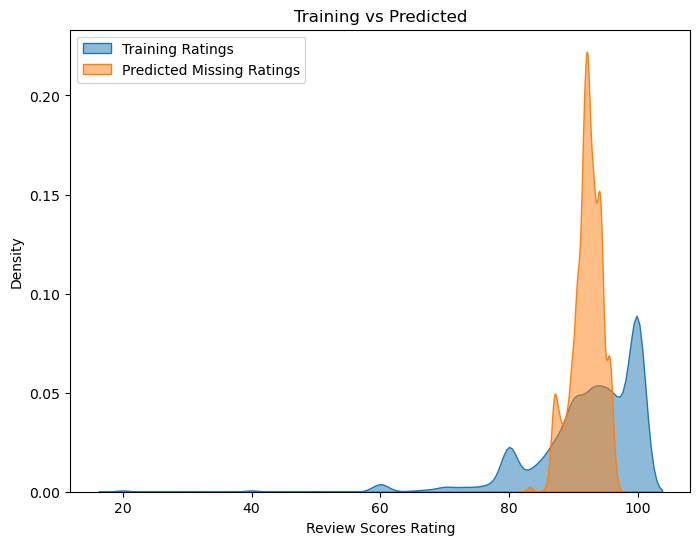

In [ ]:
#6
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.kdeplot(y_train, label='Training Ratings', fill=True, alpha=0.5)
sns.kdeplot(predicted_ratings, label='Predicted Missing Ratings', fill=True, alpha=0.5)
plt.xlabel('Review Scores Rating')
plt.ylabel('Density')
plt.title('Training vs Predicted')
plt.legend()
plt.show()
#Both distributions have similar shapes and look quite similar, being centered around 90/95 for each. The training ratings have a wider spread 
#and the predicted ratings have a tighter density but they still follow the same general shape. This means that our filling of missing values 
#was very reasonable and it captured our overall distribution nicely.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)